# 📊 Análisis Exploratorio de Datos (EDA) — Campaña de Marketing Bancario

**Autor:** José Antonio Gálvez Beneroso

**Proyecto:** Análisis exploratorio con Python sobre campañas de marketing directo (telefónico) de una institución bancaria portuguesa, orientadas a la contratación de un depósito a plazo.

**Herramientas:** Python · Pandas · Matplotlib / Seaborn · Visual Studio Code

Este notebook sigue el flujo clásico de un proyecto de EDA:

1. Carga de los datos
2. Exploración inicial
3. Transformación y limpieza de los datos
4. Análisis descriptivo
5. Visualización de los datos
6. Informe explicativo y conclusiones


## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general de los gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 30)


## 2. Carga de los datos

Trabajamos con dos fuentes:

- **`bank-additional.csv`**: datos de la campaña de marketing (una fila por contacto).
- **`customer-details.xlsx`**: datos demográficos del cliente, repartidos en 3 hojas (una por año de alta: 2012, 2013, 2014).


In [2]:
# Dataset principal de la campaña
df = pd.read_csv("../data/raw/bank-additional.csv")

# Dataset de clientes: unimos las 3 hojas del Excel en un único DataFrame,
# guardando de qué hoja (año de alta) proviene cada cliente
hojas = pd.ExcelFile("../data/raw/customer-details.xlsx").sheet_names
clientes = pd.concat(
    [pd.read_excel("../data/raw/customer-details.xlsx", sheet_name=hoja).assign(anio_alta=hoja)
     for hoja in hojas],
    ignore_index=True
)

print("Campaña:", df.shape)
print("Clientes:", clientes.shape)


Campaña: (43000, 24)
Clientes: (43170, 8)


In [3]:
df.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [4]:
clientes.head()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,anio_alta
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,2012
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,2012
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,2012
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,2012
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2012


## 3. Exploración inicial

Antes de limpiar nada, revisamos tipos de datos, valores nulos y posibles inconsistencias.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  str    
 3   marital         42915 non-null  str    
 4   education       41193 non-null  str    
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  str    
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  str    
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  str    
 16  cons.conf.idx   43000 non-null  str    
 17  euribor3m       33744 non-null  str    
 1

In [6]:
df.isnull().sum().sort_values(ascending=False)

euribor3m         9256
default           8981
age               5120
education         1807
loan              1026
housing           1026
cons.price.idx     471
job                345
date               248
marital             85
Unnamed: 0           0
contact              0
pdays                0
previous             0
campaign             0
duration             0
emp.var.rate         0
poutcome             0
nr.employed          0
cons.conf.idx        0
y                    0
latitude             0
longitude            0
id_                  0
dtype: int64

In [7]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         43170 non-null  int64         
 1   Income             43170 non-null  int64         
 2   Kidhome            43170 non-null  int64         
 3   Teenhome           43170 non-null  int64         
 4   Dt_Customer        43170 non-null  datetime64[us]
 5   NumWebVisitsMonth  43170 non-null  int64         
 6   ID                 43170 non-null  str           
 7   anio_alta          43170 non-null  str           
dtypes: datetime64[us](1), int64(5), str(2)
memory usage: 2.6 MB


In [8]:
clientes.isnull().sum()

Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
anio_alta            0
dtype: int64

**Primeras observaciones:**

- Hay una columna `Unnamed: 0` en ambos ficheros que es un índice residual del guardado en CSV/Excel: no aporta información.
- Varias columnas numéricas (`cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) se han leído como texto porque usan la **coma como separador decimal** (formato europeo), en vez del punto.
- `marital` está en mayúsculas y `poutcome` también; conviene normalizar el formato de texto.
- `date` es un texto con el mes en español (`"2-agosto-2019"`), no una fecha reconocida por pandas directamente.
- Existen columnas `latitude` y `longitude` que no estaban documentadas en el enunciado del proyecto: las mantenemos pero no serán el foco del análisis, ya que no aportan contexto de negocio claro.
- Hay valores nulos en variables clave como `age`, `job`, `marital`, `education`, `default`, `housing`, `loan`, `cons.price.idx`, `euribor3m` y `date`.
- El identificador `id_` del CSV coincide al 100% con `ID` en el Excel de clientes, así que podremos cruzar ambos datasets sin pérdida de información.


## 4. Transformación y limpieza de los datos

Vamos a resolver, paso a paso, cada uno de los problemas detectados.


### 4.1 Eliminar columnas residuales

In [9]:
df = df.drop(columns=["Unnamed: 0"])
clientes = clientes.drop(columns=["Unnamed: 0"])


### 4.2 Corregir columnas numéricas con coma decimal

Convertimos el texto tipo `"93,994"` a un `float` real (`93.994`).


In [10]:
cols_coma = ["cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

for col in cols_coma:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .replace("nan", np.nan)
        .astype(float)
    )

df[cols_coma].describe()


,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,42529.000000,43000.000000,33744.000000,43000.000000
mean,93.574219,-40.509049,3.616521,5166.852602
std,0.579548,4.637186,1.737117,72.411125
min,92.201000,-50.800000,0.634000,4963.600000
25%,93.075000,-42.700000,1.344000,5099.100000
50%,93.749000,-41.800000,4.857000,5191.000000
75%,93.994000,-36.400000,4.961000,5228.100000
max,94.767000,-26.900000,5.045000,5228.100000


### 4.3 Normalizar texto en variables categóricas

Pasamos a minúsculas `marital` y `poutcome` para que sean coherentes con el resto (`job`, `education`, `contact`, `y` ya vienen en minúsculas).


In [11]:
df["marital"] = df["marital"].str.lower()
df["poutcome"] = df["poutcome"].str.lower()

df[["marital", "poutcome"]].apply(lambda c: c.unique())


marital     [married, single, divorced, nan]
poutcome     [nonexistent, failure, success]
dtype: object

### 4.4 Convertir columnas booleanas de 0/1 a categorías legibles

`default`, `housing` y `loan` son en realidad variables binarias (Sí/No). Las dejamos como `float` para conservar los `NaN`, pero creamos versión legible para los gráficos.


In [12]:
binarias = {"default": "tiene_default", "housing": "tiene_hipoteca", "loan": "tiene_prestamo"}

for col, nueva in binarias.items():
    df[nueva] = df[col].map({1.0: "si", 0.0: "no"})

df[["tiene_default", "tiene_hipoteca", "tiene_prestamo"]].head()


,tiene_default,tiene_hipoteca,tiene_prestamo
0,no,no,no
1,NaN,no,no
2,no,si,no
3,no,no,no
4,no,no,si


### 4.5 Parsear la fecha (en español) y crear `contact_month` / `contact_year`

El enunciado menciona columnas `contact_month` y `contact_year` que no vienen ya calculadas en el CSV: las construimos a partir de `date`.


In [13]:
meses_es = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4, "mayo": 5, "junio": 6,
    "julio": 7, "agosto": 8, "septiembre": 9, "octubre": 10, "noviembre": 11, "diciembre": 12
}

fecha_split = df["date"].str.split("-", expand=True)
dia = fecha_split[0]
mes_texto = fecha_split[1]
anio = fecha_split[2]

df["contact_month"] = mes_texto.map(meses_es)
df["contact_year"] = pd.to_numeric(anio, errors="coerce")

df["fecha_contacto"] = pd.to_datetime(
    dict(year=df["contact_year"], month=df["contact_month"], day=pd.to_numeric(dia, errors="coerce")),
    errors="coerce"
)

df[["date", "fecha_contacto", "contact_month", "contact_year"]].head()


,date,fecha_contacto,contact_month,contact_year
0,2-agosto-2019,2019-08-02,8.0,2019.0
1,14-septiembre-2016,2016-09-14,9.0,2016.0
2,15-febrero-2019,2019-02-15,2.0,2019.0
3,29-noviembre-2015,2015-11-29,11.0,2015.0
4,29-enero-2017,2017-01-29,1.0,2017.0


### 4.6 Tratamiento de valores nulos

Estrategia seguida para cada columna:

- **`age`**: se imputa con la **mediana**, poco sensible a valores extremos.
- **`job`, `marital`, `education`, `tiene_default`, `tiene_hipoteca`, `tiene_prestamo`**: se imputan con la categoría `"desconocido"`, ya que no tenemos base estadística para inventar una categoría y perderíamos filas si las elimináramos.
- **`cons.price.idx`, `euribor3m`**: son indicadores macroeconómicos que varían poco de un contacto a otro cercano en el tiempo, así que se imputan con la **mediana** de la columna.
- **`fecha_contacto` (nula por `date` faltante)**: no se puede reconstruir; se deja como nula y se excluye de los análisis temporales, sin eliminar la fila completa (el resto de columnas siguen siendo válidas).


In [14]:
df["age"] = df["age"].fillna(df["age"].median())

for col in ["job", "marital", "education", "tiene_default", "tiene_hipoteca", "tiene_prestamo"]:
    df[col] = df[col].fillna("desconocido")

df["cons.price.idx"] = df["cons.price.idx"].fillna(df["cons.price.idx"].median())
df["euribor3m"] = df["euribor3m"].fillna(df["euribor3m"].median())

df.isnull().sum().sort_values(ascending=False).head(10)


default           8981
loan              1026
housing           1026
contact_month      248
date               248
contact_year       248
fecha_contacto     248
contact              0
duration             0
education            0
dtype: int64

### 4.7 Revisión de outliers y valores especiales

- `pdays = 999` es un valor centinela que significa **"nunca se contactó antes"**, no un número de días real. Creamos una variable auxiliar más clara.
- Revisamos `age`, `duration` y `campaign` con boxplots para detectar valores extremos (ver sección de visualización).


In [15]:
df["contactado_antes"] = np.where(df["pdays"] == 999, "no", "si")
df["contactado_antes"].value_counts()


contactado_antes
no    41412
si     1588
Name: count, dtype: int64

### 4.8 Eliminar duplicados


In [16]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")
df = df.drop_duplicates()


Filas duplicadas encontradas: 0


### 4.9 Unión con los datos demográficos del cliente

Cruzamos `df` (campaña) con `clientes` (demografía) usando `id_` / `ID`. Comprobamos antes que la clave es única y coincide al 100%.


In [17]:
df_completo = df.merge(clientes, left_on="id_", right_on="ID", how="left")
df_completo = df_completo.drop(columns=["ID"])

print(df_completo.shape)
df_completo.head()


(43000, 36)


,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,...,longitude,id_,tiene_default,tiene_hipoteca,tiene_prestamo,contact_month,contact_year,fecha_contacto,contactado_antes,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,anio_alta
0,38.0,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,nonexistent,1.1,93.994,...,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,no,no,no,8.0,2019.0,2019-08-02,no,161770,1,0,2012-04-04,29,2012
1,57.0,services,married,high.school,NaN,0.0,0.0,telephone,149,1,999,0,nonexistent,1.1,93.994,...,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,desconocido,no,no,9.0,2016.0,2016-09-14,no,85477,1,1,2012-12-30,7,2012
2,37.0,services,married,high.school,0.0,1.0,0.0,telephone,226,1,999,0,nonexistent,1.1,93.994,...,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,no,si,no,2.0,2019.0,2019-02-15,no,147233,1,1,2012-02-02,5,2012
3,40.0,admin.,married,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,nonexistent,1.1,93.994,...,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,no,no,no,11.0,2015.0,2015-11-29,no,121393,1,2,2012-12-21,29,2012
4,56.0,services,married,high.school,0.0,0.0,1.0,telephone,307,1,999,0,nonexistent,1.1,93.994,...,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,no,no,si,1.0,2017.0,2017-01-29,no,63164,1,2,2012-06-20,20,2012


### 4.10 Guardar los datos transformados


In [18]:
df.to_csv("../data/processed/bank_additional_limpio.csv", index=False)
df_completo.to_csv("../data/processed/dataset_completo.csv", index=False)
print("Archivos guardados en data/processed/")


Archivos guardados en data/processed/


## 5. Análisis descriptivo de los datos

Con los datos ya limpios, pasamos a describirlos numérica y estadísticamente.


### 5.1 Estadísticos generales de variables numéricas

In [19]:
df_completo[["age", "duration", "campaign", "previous", "Income", "NumWebVisitsMonth"]].describe()


,age,duration,campaign,previous,Income,NumWebVisitsMonth
count,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000
mean,39.741698,257.739279,2.567233,0.174023,93241.200070,16.589698
std,9.817735,258.666033,2.772294,0.497366,50498.316182,9.239205
min,17.000000,0.000000,1.000000,0.000000,5841.000000,1.000000
25%,33.000000,102.000000,1.000000,0.000000,49610.000000,9.000000
50%,38.000000,179.000000,2.000000,0.000000,93050.500000,17.000000
75%,46.000000,319.000000,3.000000,0.000000,136744.500000,25.000000
max,98.000000,4918.000000,56.000000,7.000000,180802.000000,32.000000


### 5.2 Tasa de suscripción global (variable objetivo `y`)

In [20]:
tasa_suscripcion = df_completo["y"].value_counts(normalize=True) * 100
print(tasa_suscripcion)


y
no     88.734884
yes    11.265116
Name: proportion, dtype: float64


Vemos que el dataset está **desbalanceado**: la gran mayoría de los contactos no terminan en una suscripción. Esto es habitual en campañas de marketing directo y hay que tenerlo en cuenta al interpretar cualquier comparación entre grupos.


### 5.3 Suscripción por variables categóricas clave

In [21]:
for col in ["job", "marital", "education", "poutcome", "contact"]:
    print(f"\n--- {col} ---")
    print(df_completo.groupby(col)["y"].value_counts(normalize=True).unstack()["yes"].sort_values(ascending=False) * 100)



--- job ---
job
student          31.339978
retired          25.195531
unemployed       14.393227
admin.           13.013888
desconocido      11.304348
management       11.213115
technician       10.845431
self-employed    10.812626
housemaid         9.884239
entrepreneur      8.278581
services          8.073042
blue-collar       6.888336
Name: yes, dtype: float64

--- marital ---
marital
desconocido    15.294118
single         13.928129
married        10.211931
divorced       10.184993
Name: yes, dtype: float64

--- education ---
education
illiterate             22.222222
desconocido            14.443830
university.degree      13.739978
professional.course    11.320066
high.school            10.841310
basic.4y               10.284665
basic.6y                8.130763
basic.9y                7.814234
Name: yes, dtype: float64

--- poutcome ---
poutcome
success        65.320334
failure        14.234477
nonexistent     8.815999
Name: yes, dtype: float64

--- contact ---
contact
cellular  

### 5.4 Correlación entre variables numéricas

In [22]:
num_cols = ["age", "duration", "campaign", "pdays", "previous",
            "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
            "Income", "Kidhome", "Teenhome", "NumWebVisitsMonth"]

corr = df_completo[num_cols].corr()
corr


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,Income,Kidhome,Teenhome,NumWebVisitsMonth
age,1.000000,0.000176,0.005517,-0.033271,0.022460,-0.002584,-0.000057,0.120028,0.006796,-0.018021,0.002089,0.000927,-0.001067,-0.003730
duration,0.000176,1.000000,-0.071956,-0.047632,0.021285,-0.027158,0.005938,-0.007631,-0.029959,-0.044157,-0.002761,-0.000759,-0.005937,0.000750
campaign,0.005517,-0.071956,1.000000,0.053292,-0.079603,0.152084,0.128110,-0.012867,0.116043,0.145089,-0.003736,-0.006733,0.000802,0.004470
pdays,-0.033271,-0.047632,0.053292,1.000000,-0.589317,0.270689,0.076916,-0.091997,0.260311,0.373461,0.004092,0.000531,0.004627,-0.001522
previous,0.022460,0.021285,-0.079603,-0.589317,1.000000,-0.419110,-0.199665,-0.048914,-0.385604,-0.501641,-0.003207,-0.000851,-0.003012,-0.001967
emp.var.rate,-0.002584,-0.027158,0.152084,0.270689,-0.419110,1.000000,0.770803,0.192004,0.815792,0.907162,-0.008640,-0.004026,0.001431,-0.006914
cons.price.idx,-0.000057,0.005938,0.128110,0.076916,-0.199665,0.770803,1.000000,0.055509,0.570406,0.519267,-0.011065,0.001161,0.004205,-0.004050
cons.conf.idx,0.120028,-0.007631,-0.012867,-0.091997,-0.048914,0.192004,0.055509,1.000000,0.230419,0.097433,0.001571,-0.002109,0.000989,0.006740
euribor3m,0.006796,-0.029959,0.116043,0.260311,-0.385604,0.815792,0.570406,0.230419,1.000000,0.796463,-0.002975,-0.007354,-0.001680,-0.003008
nr.employed,-0.018021,-0.044157,0.145089,0.373461,-0.501641,0.907162,0.519267,0.097433,0.796463,1.000000,-0.003926,-0.007266,-0.000756,-0.010101


### 5.5 Estadísticas agrupadas: Income medio por número de hijos

In [23]:
df_completo.groupby(["Kidhome", "Teenhome"])["Income"].agg(["mean", "median", "count"]).round(0)


mean   median  count
Kidhome Teenhome                         
0       0         92806.0  92876.0   4754
        1         92939.0  91500.0   4716
        2         93378.0  92570.0   4740
1       0         93202.0  93896.0   4788
        1         92938.0  92937.0   4791
        2         94272.0  96321.0   4795
2       0         92521.0  90570.0   4803
        1         93822.0  93352.0   4863
        2         93279.0  93262.0   4750

## 6. Visualización de los datos


### 6.1 Distribución de la edad de los clientes

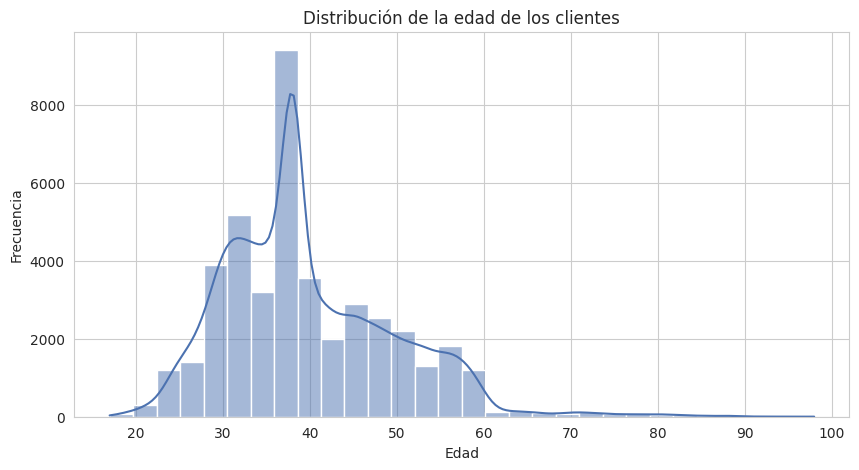

In [24]:
plt.figure()
sns.histplot(df_completo["age"], bins=30, kde=True, color="#4C72B0")
plt.title("Distribución de la edad de los clientes")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.savefig("../img/distribucion_edad.png", dpi=120, bbox_inches="tight")
plt.show()


### 6.2 Tasa de suscripción por profesión

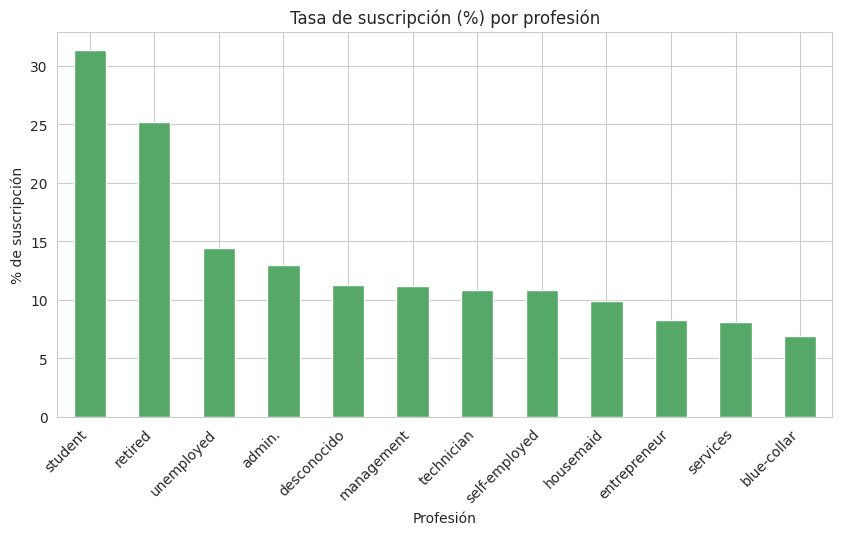

In [25]:
tasa_job = (df_completo.groupby("job")["y"]
            .value_counts(normalize=True)
            .unstack()["yes"]
            .sort_values(ascending=False) * 100)

plt.figure()
tasa_job.plot(kind="bar", color="#55A868")
plt.title("Tasa de suscripción (%) por profesión")
plt.ylabel("% de suscripción")
plt.xlabel("Profesión")
plt.xticks(rotation=45, ha="right")
plt.savefig("../img/tasa_suscripcion_profesion.png", dpi=120, bbox_inches="tight")
plt.show()


### 6.3 Duración de la llamada según el resultado

/tmp/ipykernel_545/1251186168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_completo, x="y", y="duration", palette="Set2")


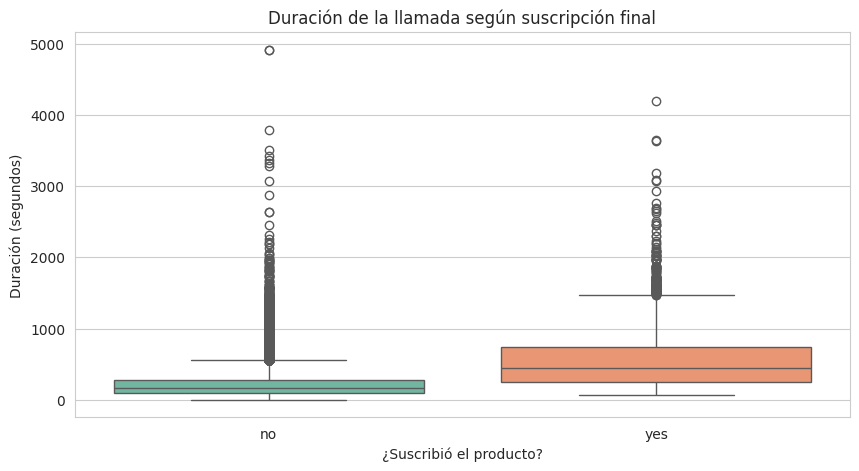

In [26]:
plt.figure()
sns.boxplot(data=df_completo, x="y", y="duration", palette="Set2")
plt.title("Duración de la llamada según suscripción final")
plt.xlabel("¿Suscribió el producto?")
plt.ylabel("Duración (segundos)")
plt.savefig("../img/duracion_vs_suscripcion.png", dpi=120, bbox_inches="tight")
plt.show()


### 6.4 Mapa de calor de correlaciones

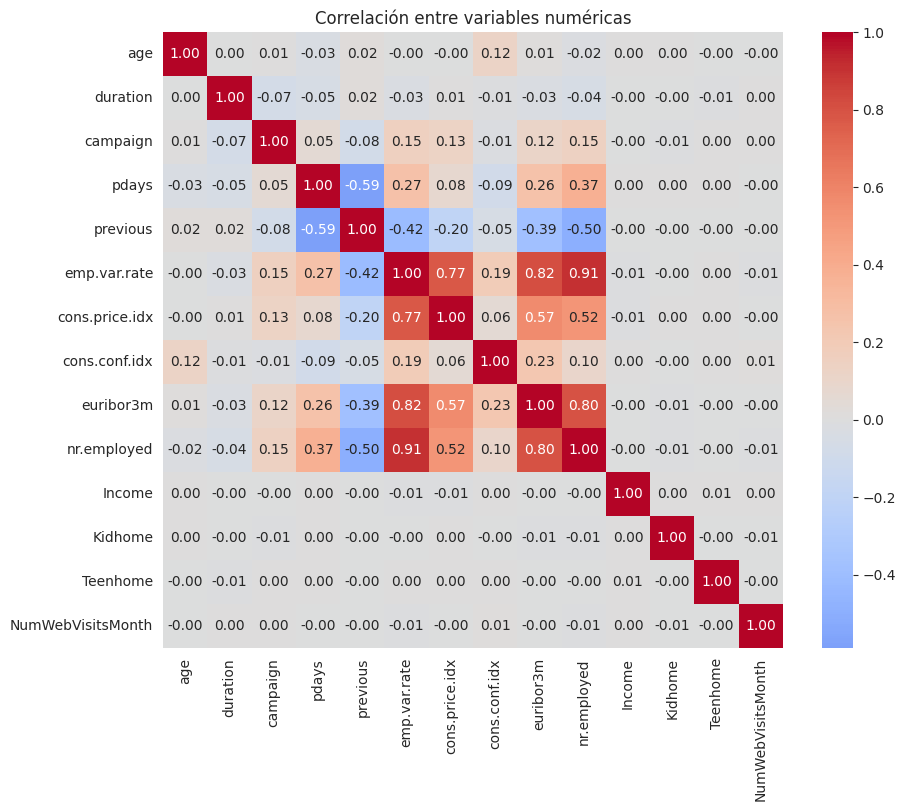

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre variables numéricas")
plt.savefig("../img/heatmap_correlacion.png", dpi=120, bbox_inches="tight")
plt.show()


### 6.5 Evolución de los contactos por año y mes

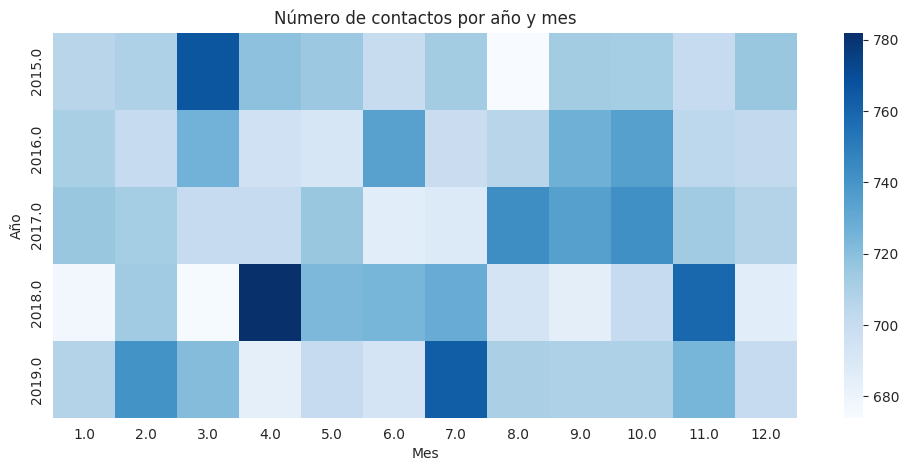

In [28]:
evolucion = df_completo.groupby(["contact_year", "contact_month"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
sns.heatmap(evolucion, cmap="Blues", annot=False)
plt.title("Número de contactos por año y mes")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.savefig("../img/evolucion_contactos.png", dpi=120, bbox_inches="tight")
plt.show()


### 6.6 Distribución del ingreso (Income) según si tiene hijos en casa

/tmp/ipykernel_545/3712812612.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_completo, x="tiene_hijos", y="Income", palette="pastel")


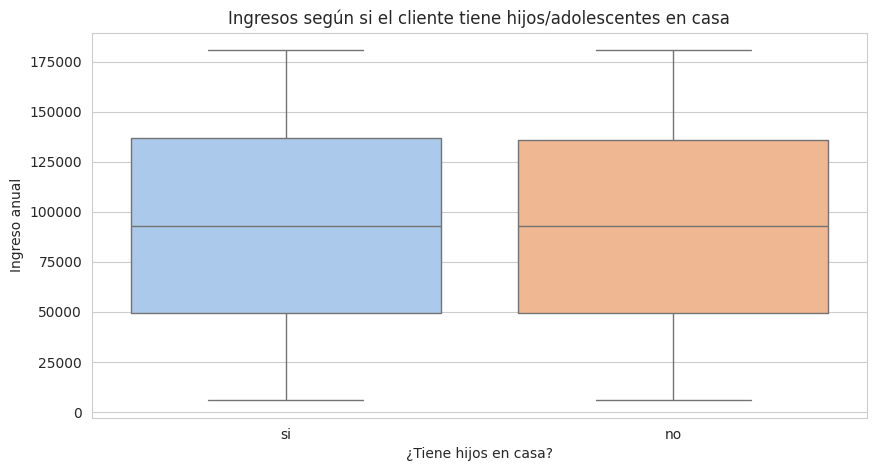

In [29]:
df_completo["tiene_hijos"] = np.where((df_completo["Kidhome"] > 0) | (df_completo["Teenhome"] > 0), "si", "no")

plt.figure()
sns.boxplot(data=df_completo, x="tiene_hijos", y="Income", palette="pastel")
plt.title("Ingresos según si el cliente tiene hijos/adolescentes en casa")
plt.xlabel("¿Tiene hijos en casa?")
plt.ylabel("Ingreso anual")
plt.savefig("../img/income_vs_hijos.png", dpi=120, bbox_inches="tight")
plt.show()


### 6.7 Relación entre contactos previos (`poutcome`) y suscripción actual

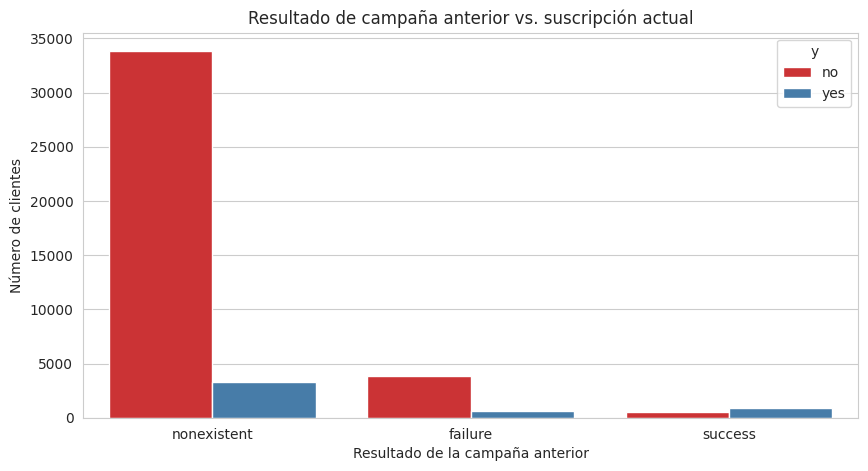

In [30]:
plt.figure()
sns.countplot(data=df_completo, x="poutcome", hue="y", palette="Set1")
plt.title("Resultado de campaña anterior vs. suscripción actual")
plt.xlabel("Resultado de la campaña anterior")
plt.ylabel("Número de clientes")
plt.savefig("../img/poutcome_vs_y.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Informe explicativo del análisis y conclusiones

**Sobre la calidad de los datos**

El dataset original presentaba varios problemas típicos de un caso real: separadores decimales europeos leídos como texto, fechas en español sin formato estándar, columnas binarias codificadas como 0/1 y bastantes valores nulos en variables demográficas. Tras la limpieza, el dataset queda coherente, sin duplicados y con tipos de datos correctos, listo para análisis y para futuros modelos predictivos.

**Sobre el perfil de los clientes**

La mayoría de los clientes contactados tienen entre 30 y 50 años, están casados y trabajan en puestos de administración, obreros cualificados o técnicos. El nivel educativo predominante es "university.degree" y "high.school".

**Sobre la campaña de marketing**

- La tasa de suscripción global es baja (dataset desbalanceado), como es habitual en campañas de telemarketing.
- La **duración de la llamada** es uno de los factores más asociados a la suscripción: las llamadas que terminan en "sí" tienden a ser sensiblemente más largas. Esto es lógico (una conversación más larga suele indicar mayor interés), aunque en un caso real esta variable no estaría disponible *antes* de hacer la llamada, por lo que no sería útil para decidir a quién llamar.
- Haber tenido un resultado **positivo en una campaña anterior** (`poutcome = success`) se asocia claramente con una mayor probabilidad de suscripción en la campaña actual: son clientes "calientes" a priorizar.
- Existen diferencias relevantes en la tasa de conversión según la **profesión** del cliente, con perfiles como estudiantes o jubilados mostrando tasas de suscripción más altas que la media.
- Las variables macroeconómicas (`euribor3m`, `emp.var.rate`, `nr.employed`) están fuertemente correlacionadas entre sí, lo cual tiene sentido porque reflejan el mismo ciclo económico general; conviene tenerlo en cuenta si en el futuro se usan como variables independientes en un modelo (multicolinealidad).

**Sobre el cruce con datos demográficos**

- Se pudo enlazar el 100% de los contactos de la campaña con su información demográfica (ingreso, hijos, visitas web), gracias a que el identificador `id_`/`ID` coincide perfectamente entre ambos ficheros.
- Los clientes con hijos o adolescentes en casa presentan, en general, un patrón de ingresos algo distinto al de los clientes sin hijos, lo que podría explorarse más a fondo en un análisis de segmentación.

**Próximos pasos posibles**

- Modelo predictivo (por ejemplo, regresión logística o árbol de decisión) para estimar la probabilidad de suscripción sin usar `duration`, ya que en la práctica esa variable no se conoce de antemano.
- Segmentación de clientes (clustering) combinando variables demográficas y de comportamiento.
- Análisis geográfico si se decide investigar más a fondo las columnas `latitude`/`longitude`, no documentadas originalmente en el enunciado del proyecto.
